# CardioVision 3D - Step 2: Preprocessing & Baselines
**Track A: Cardiovascular Risk Visualization & Prediction**

In [1]:

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from dataset_audit import locate_dataset, load_dataset, RANDOM_SEED, build_data_dictionary, audit_feature_types
from preprocessing import clean_dataset, map_targets, get_feature_lists, build_preprocessor, assert_no_leakage
from train_baselines import get_baseline_models, run_cross_validation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

import warnings
warnings.filterwarnings('ignore')


## 1. Load & Clean Dataset

In [2]:

dataset_path, exists = locate_dataset()
raw_df = load_dataset(dataset_path)

# Clean Typo
df = clean_dataset(raw_df)
print("Fmale in Sex column:", (df['Sex'] == 'Fmale').sum())


Fmale in Sex column: 0


## 2. Target Mapping

In [3]:

df = map_targets(df)
targets = ['y_cad', 'y_lad', 'y_lcx', 'y_rca']
for t in targets:
    print(f"{t} Distribution:\n", df[t].value_counts())


y_cad Distribution:
 y_cad
1    216
0     87
Name: count, dtype: int64
y_lad Distribution:
 y_lad
1    177
0    126
Name: count, dtype: int64
y_lcx Distribution:
 y_lcx
0    184
1    119
Name: count, dtype: int64
y_rca Distribution:
 y_rca
0    189
1    114
Name: count, dtype: int64


## 3. Feature Selection & Preprocessor

In [4]:

# Build feature dictionary to get types
data_dict = build_data_dictionary(raw_df)
feature_types = audit_feature_types(raw_df)

numerical, categorical, binary = get_feature_lists(df, feature_types)
print(f"Candidate Features count: {len(numerical) + len(categorical) + len(binary)}")

# Build Preprocessor
preprocessor = build_preprocessor(numerical, categorical, binary)

# Validate Preprocessor Feature Count
preprocessor.fit(df)
try:
    final_features_count = len(preprocessor.get_feature_names_out())
    print(f"Final transformed feature count: {final_features_count}")
except:
    print("Preprocessed feature count check bypassed for now.")


Candidate Features count: 54
Final transformed feature count: 66


## 4. Run Baseline Experiments

In [5]:

baseline_models = get_baseline_models()
all_results = []
oof_dict = {}

# Excluded columns
excluded = ['Cath', 'LAD', 'LCX', 'RCA', 'Exertional CP']
for t in targets:
    excluded.append(t)

X = df.drop(columns=[col for col in excluded if col in df.columns], errors='ignore')
assert_no_leakage(X, ['Cath', 'LAD', 'LCX', 'RCA'], ['Exertional CP'])

for target in targets:
    print(f"\n{'='*40}\nEvaluating Target: {target}\n{'='*40}")
    y = df[target]
    
    oof_predictions_target = {}
    
    for model_name, model in baseline_models.items():
        print(f"Training {model_name}...")
        metrics, oof = run_cross_validation(X, y, model, preprocessor, n_splits=5)
        
        # Add metadata
        metrics['target'] = target
        metrics['model'] = model_name.split(' (')[0]
        metrics['class_weight'] = 'balanced' if 'Balanced' in model_name else 'default'
        metrics['cv_folds'] = 5
        
        all_results.append(metrics)
        oof_predictions_target[model_name] = oof
        
    oof_dict[target] = oof_predictions_target



Evaluating Target: y_cad
Training Logistic Regression (Default)...


Training Logistic Regression (Balanced)...


Training Random Forest (Default)...


Training Random Forest (Balanced)...


Training Gradient Boosting (Default)...


...

Training Random Forest (Default)...


Training Random Forest (Balanced)...


Training Gradient Boosting (Default)...


Training SVM (Default)...


Training SVM (Balanced)...


## 5. Save Results & OOF Predictions

In [6]:

results_df = pd.DataFrame(all_results)
results_cols = ['target', 'model', 'class_weight', 'cv_folds', 
               'roc_auc_mean', 'roc_auc_std', 'pr_auc_mean', 'pr_auc_std',
               'f1_mean', 'f1_std', 'accuracy_mean', 'accuracy_std',
               'precision_mean', 'precision_std', 'recall_mean', 'recall_std',
               'specificity_mean', 'specificity_std']
results_df = results_df[results_cols]

os.makedirs('../reports', exist_ok=True)
results_df.to_csv('../reports/model_baseline_results.csv', index=False)
print("Saved baseline results to ml/reports/model_baseline_results.csv")

for target, oof_target_dict in oof_dict.items():
    # Save OOF for best model based on ROC AUC (for simplicity)
    target_results = results_df[results_df['target'] == target]
    best_config = target_results.loc[target_results['roc_auc_mean'].idxmax()]
    best_model_key = f"{best_config['model']} ({best_config['class_weight'].capitalize()})"
    
    best_oof = oof_target_dict.get(best_model_key)
    if best_oof is None:
        best_oof = oof_target_dict[list(oof_target_dict.keys())[0]] # fallback
        
    # Standardize column naming
    best_oof.to_csv(f'../reports/oof_predictions_{target.split("_")[1]}.csv', index=False)
    print(f"Saved OOF predictions for {target} to ml/reports/oof_predictions_{target.split('_')[1]}.csv")


Saved baseline results to ml/reports/model_baseline_results.csv
Saved OOF predictions for y_cad to ml/reports/oof_predictions_cad.csv
Saved OOF predictions for y_lad to ml/reports/oof_predictions_lad.csv
Saved OOF predictions for y_lcx to ml/reports/oof_predictions_lcx.csv
Saved OOF predictions for y_rca to ml/reports/oof_predictions_rca.csv


## 6. Visualizations: Confusion Matrices & Curves

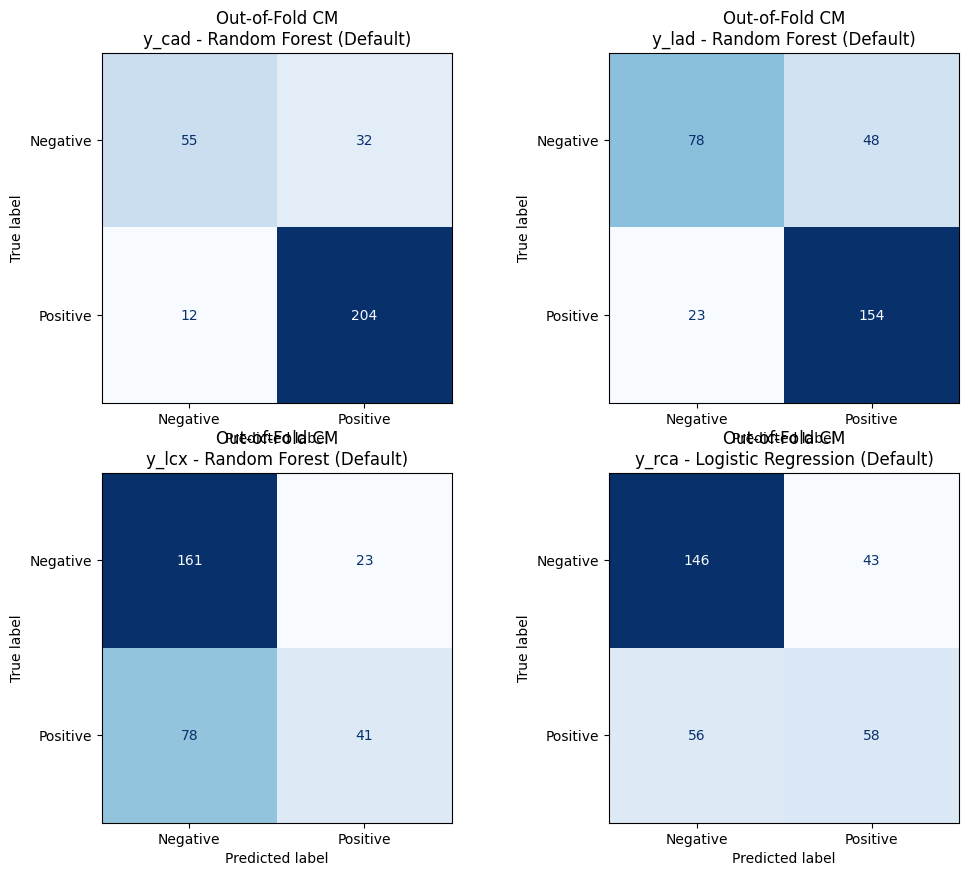

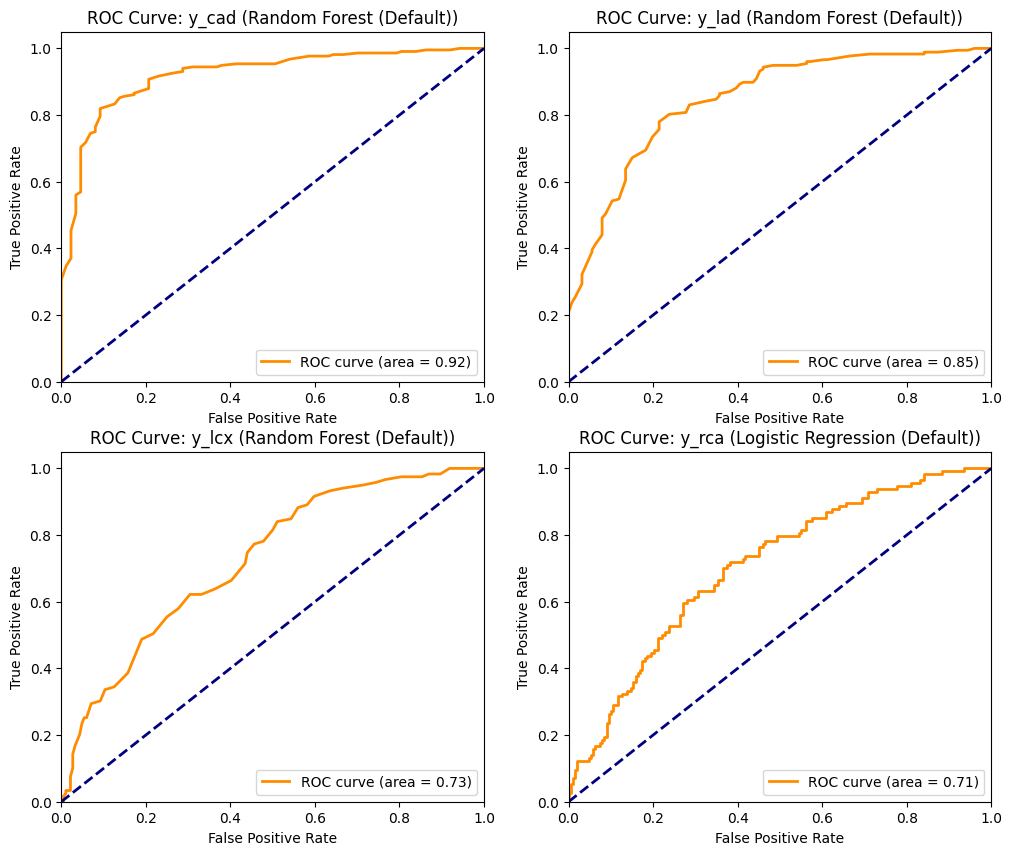

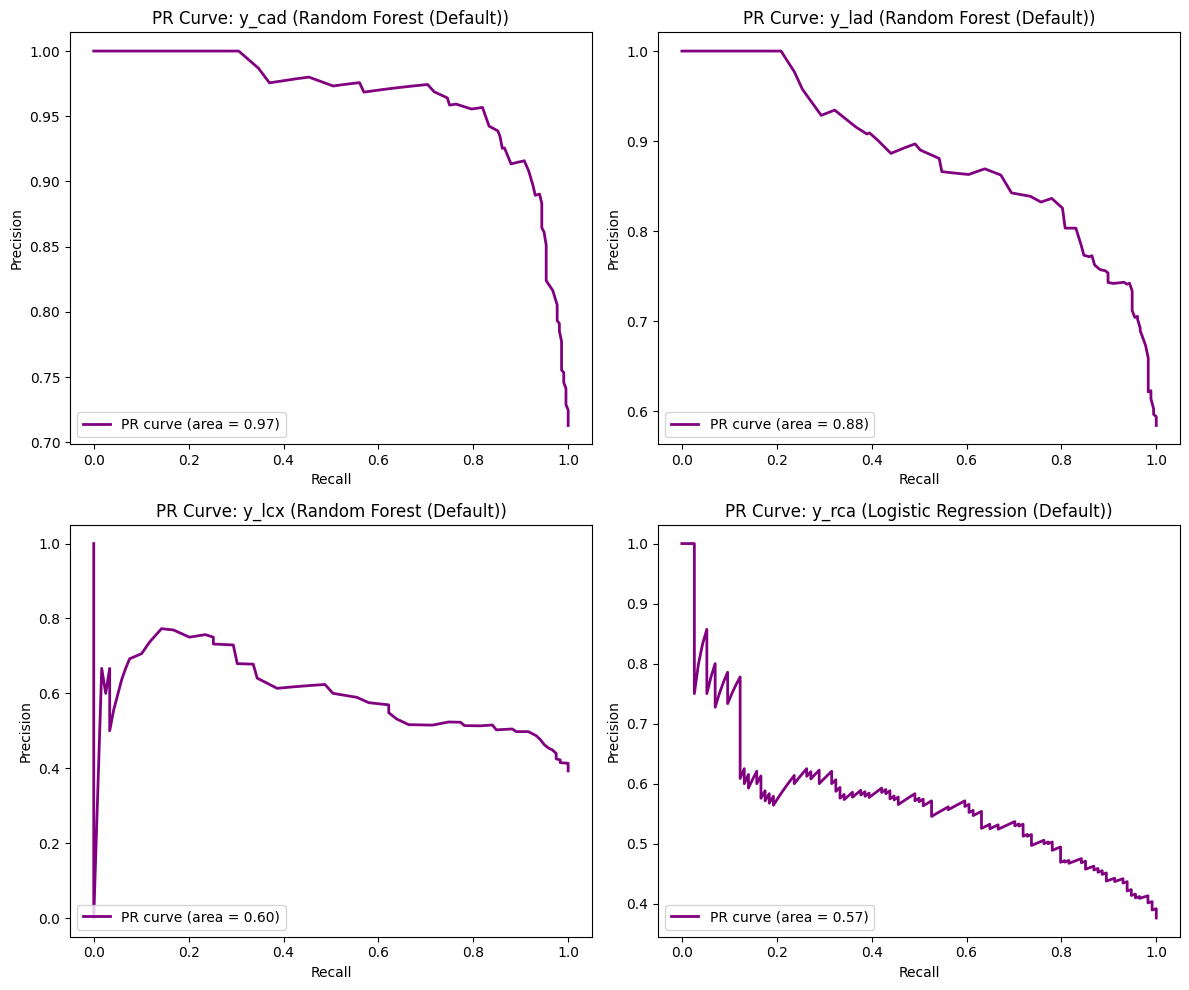

In [7]:

fig_cm, axes_cm = plt.subplots(2, 2, figsize=(12, 10))
fig_roc, axes_roc = plt.subplots(2, 2, figsize=(12, 10))
fig_pr, axes_pr = plt.subplots(2, 2, figsize=(12, 10))

for idx, target in enumerate(targets):
    target_results = results_df[results_df['target'] == target]
    best_config = target_results.loc[target_results['roc_auc_mean'].idxmax()]
    best_model_key = f"{best_config['model']} ({best_config['class_weight'].capitalize()})"
    oof = oof_dict[target][best_model_key]
    
    y_true = oof['true_label']
    y_pred = oof['predicted_class']
    y_prob = oof['predicted_probability']
    
    # Confusion Matrix
    ax_cm = axes_cm.flatten()[idx]
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax_cm, cmap='Blues', colorbar=False)
    ax_cm.set_title(f"Out-of-Fold CM\n{target} - {best_model_key}")
    
    # ROC Curve
    ax_roc = axes_roc.flatten()[idx]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'ROC Curve: {target} ({best_model_key})')
    ax_roc.legend(loc="lower right")
    
    # PR Curve
    ax_pr = axes_pr.flatten()[idx]
    precision_c, recall_c, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_c, precision_c)
    ax_pr.plot(recall_c, precision_c, color='purple', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'PR Curve: {target} ({best_model_key})')
    ax_pr.legend(loc="lower left")

plt.tight_layout()


## 7. Model Experiment Summary Table

In [8]:

summary_df = results_df.copy()
# Format the display table nicely
summary_df['Model_Config'] = summary_df['model'] + " (" + summary_df['class_weight'] + ")"
summary_df['ROC_AUC'] = summary_df['roc_auc_mean'].round(3).astype(str) + " ± " + summary_df['roc_auc_std'].round(3).astype(str)
summary_df['PR_AUC'] = summary_df['pr_auc_mean'].round(3).astype(str) + " ± " + summary_df['pr_auc_std'].round(3).astype(str)
summary_df['F1'] = summary_df['f1_mean'].round(3).astype(str) + " ± " + summary_df['f1_std'].round(3).astype(str)

for target in targets:
    print(f"\n{'='*50}\nSummary for {target}\n{'='*50}")
    display(summary_df[summary_df['target'] == target][['Model_Config', 'ROC_AUC', 'PR_AUC', 'F1', 'recall_mean', 'specificity_mean']].set_index('Model_Config'))
    
    # Best baseline
    best = summary_df[summary_df['target'] == target].loc[summary_df[summary_df['target'] == target]['roc_auc_mean'].idxmax()]
    print(f"Best baseline configuration under this validation setup for {target}: {best['Model_Config']}")



Summary for y_cad


,ROC_AUC,PR_AUC,F1,recall_mean,specificity_mean
Model_Config,,,,,
Logistic Regression (default),0.927 ± 0.036,0.969 ± 0.012,0.901 ± 0.035,0.911945,0.723529
Logistic Regression (balanced),0.925 ± 0.041,0.969 ± 0.014,0.888 ± 0.033,0.865539,0.792810
Random Forest (default),0.928 ± 0.044,0.968 ± 0.02,0.903 ± 0.028,0.944292,0.633987
Random Forest (balanced),0.921 ± 0.048,0.961 ± 0.025,0.894 ± 0.03,0.948943,0.566013
Gradient Boosting (default),0.91 ± 0.037,0.964 ± 0.016,0.89 ± 0.03,0.921247,0.633333
SVM (default),0.909 ± 0.041,0.951 ± 0.032,0.902 ± 0.025,0.935095,0.655556
SVM (balanced),0.909 ± 0.045,0.957 ± 0.022,0.896 ± 0.029,0.884144,0.781699


Best baseline configuration under this validation setup for y_cad: Random Forest (default)

Summary for y_lad


,ROC_AUC,PR_AUC,F1,recall_mean,specificity_mean
Model_Config,,,,,
Logistic Regression (default),0.82 ± 0.034,0.858 ± 0.032,0.771 ± 0.026,0.774127,0.674462
Logistic Regression (balanced),0.818 ± 0.034,0.856 ± 0.033,0.744 ± 0.049,0.712222,0.722154
Random Forest (default),0.848 ± 0.038,0.881 ± 0.031,0.813 ± 0.025,0.870159,0.619077
Random Forest (balanced),0.843 ± 0.051,0.871 ± 0.043,0.83 ± 0.044,0.887460,0.642154
Gradient Boosting (default),0.842 ± 0.061,0.886 ± 0.047,0.805 ± 0.037,0.814127,0.706154
SVM (default),0.82 ± 0.058,0.846 ± 0.059,0.791 ± 0.036,0.859206,0.564000
SVM (balanced),0.815 ± 0.057,0.853 ± 0.051,0.762 ± 0.032,0.768413,0.650462


Best baseline configuration under this validation setup for y_lad: Random Forest (default)

Summary for y_lcx


,ROC_AUC,PR_AUC,F1,recall_mean,specificity_mean
Model_Config,,,,,
Logistic Regression (default),0.66 ± 0.053,0.54 ± 0.072,0.494 ± 0.02,0.478986,0.700300
Logistic Regression (balanced),0.657 ± 0.055,0.538 ± 0.076,0.55 ± 0.025,0.596014,0.629730
Random Forest (default),0.718 ± 0.078,0.589 ± 0.089,0.448 ± 0.059,0.344203,0.875075
Random Forest (balanced),0.708 ± 0.057,0.568 ± 0.074,0.424 ± 0.111,0.335507,0.853453
Gradient Boosting (default),0.704 ± 0.068,0.584 ± 0.066,0.557 ± 0.064,0.539130,0.750300
SVM (default),0.699 ± 0.062,0.576 ± 0.064,0.483 ± 0.058,0.411594,0.814715
SVM (balanced),0.702 ± 0.078,0.58 ± 0.084,0.624 ± 0.1,0.664130,0.689640


Best baseline configuration under this validation setup for y_lcx: Random Forest (default)

Summary for y_rca


,ROC_AUC,PR_AUC,F1,recall_mean,specificity_mean
Model_Config,,,,,
Logistic Regression (default),0.71 ± 0.028,0.572 ± 0.043,0.532 ± 0.071,0.508696,0.772973
Logistic Regression (balanced),0.708 ± 0.026,0.574 ± 0.046,0.577 ± 0.029,0.622530,0.682930
Random Forest (default),0.681 ± 0.062,0.553 ± 0.095,0.4 ± 0.067,0.306719,0.878521
Random Forest (balanced),0.694 ± 0.048,0.579 ± 0.062,0.386 ± 0.057,0.288933,0.883784
Gradient Boosting (default),0.668 ± 0.044,0.581 ± 0.044,0.471 ± 0.043,0.411858,0.804836
SVM (default),0.698 ± 0.03,0.577 ± 0.048,0.399 ± 0.101,0.314229,0.867852
SVM (balanced),0.706 ± 0.028,0.574 ± 0.046,0.581 ± 0.066,0.620949,0.699147


Best baseline configuration under this validation setup for y_rca: Logistic Regression (default)
